In [ ]:
!pip install -q earthengine-api geemap geopandas rasterio folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 90.6 MB/s eta 0:00:00


In [ ]:
import ee
import geemap
import geopandas as gpd
import matplotlib.pyplot as plt
import zipfile
import os
import requests
import pandas as pd
import numpy as np

from PIL import Image
from io import BytesIO

In [ ]:
ee.Authenticate()
ee.Initialize(project='urban-heat-island-kolkata')

In [ ]:
zip_path = "gadm41_IND_shp.zip"

with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall("gadm_data")

print(os.listdir("gadm_data"))

['gadm41_IND_0.cpg', 'gadm41_IND_1.cpg', 'gadm41_IND_1.dbf', 'gadm41_IND_2.dbf', 'gadm41_IND_1.shx', 'gadm41_IND_3.shx', 'gadm41_IND_3.shp', 'gadm41_IND_3.prj', 'gadm41_IND_1.shp', 'gadm41_IND_3.dbf', 'gadm41_IND_3.cpg', 'gadm41_IND_2.shx', 'gadm41_IND_0.dbf', 'gadm41_IND_2.prj', 'gadm41_IND_0.prj', 'gadm41_IND_2.shp', 'gadm41_IND_0.shx', 'gadm41_IND_1.prj', 'gadm41_IND_0.shp', 'gadm41_IND_2.cpg']


In [ ]:
districts = gpd.read_file(
    "gadm_data/gadm41_IND_2.shp"
)

districts[['NAME_1','NAME_2']].head()

,NAME_1,NAME_2
0,Andaman and Nicobar,Nicobar Islands
1,Andaman and Nicobar,North and Middle Andaman
2,Andaman and Nicobar,South Andaman
3,Andhra Pradesh,Anantapur
4,Andhra Pradesh,Chittoor


In [ ]:
kolkata = districts[
    districts['NAME_2']=="Kolkata"
]

kolkata

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
666,IND.36.11_1,IND,India,IND.36_1,West Bengal,NA,Kolkata,Calcutta,NA,District,District,NA,IN.WB.KO,"POLYGON ((88.27065 22.55176, 88.2836 22.54805,..."


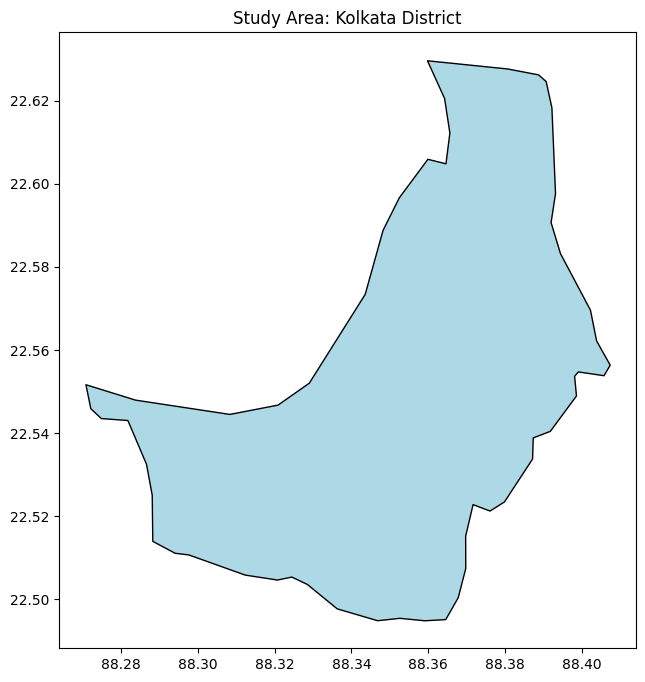

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))

kolkata.plot(
    ax=ax,
    color='lightblue',
    edgecolor='black'
)

ax.set_title(
    "Study Area: Kolkata District"
)

plt.show()

In [ ]:
aoi = geemap.geopandas_to_ee(kolkata)

In [ ]:
landsat = (
    ee.ImageCollection(
        "LANDSAT/LC08/C02/T1_L2"
    )
    .filterBounds(aoi)
    .filterDate(
        "2023-04-01",
        "2023-06-30"
    )
    .filter(
        ee.Filter.lt(
            'CLOUD_COVER',
            10
        )
    )
    .median()
    .clip(aoi)
)

print("Landsat Loaded Successfully")

Landsat Loaded Successfully


In [ ]:
ndvi = landsat.normalizedDifference(
    ['SR_B5','SR_B4']
).rename('NDVI')

In [ ]:
ndbi = landsat.normalizedDifference(
    ['SR_B6','SR_B5']
).rename('NDBI')

In [ ]:
lst = (
    landsat.select('ST_B10')
    .multiply(0.00341802)
    .add(149.0)
    .subtract(273.15)
    .rename('LST')
)

In [ ]:
stats = lst.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=aoi.geometry(),
    scale=30,
    maxPixels=1e13
)

print(stats.getInfo())

{'LST_max': 56.591479580000055, 'LST_min': 33.81721232000001}


In [ ]:
percentiles = lst.reduceRegion(
    reducer=ee.Reducer.percentile(
        [20,40,60,80]
    ),
    geometry=aoi.geometry(),
    scale=30,
    maxPixels=1e13
)

p20 = ee.Number(
    percentiles.get('LST_p20')
)

p40 = ee.Number(
    percentiles.get('LST_p40')
)

p60 = ee.Number(
    percentiles.get('LST_p60')
)

p80 = ee.Number(
    percentiles.get('LST_p80')
)

lst_class = lst.expression(
"""
b('LST') <= p20 ? 1 :
b('LST') <= p40 ? 2 :
b('LST') <= p60 ? 3 :
b('LST') <= p80 ? 4 :
5
""",
{
'p20':p20,
'p40':p40,
'p60':p60,
'p80':p80
}
).rename('LST_Class')

In [ ]:
p90 = lst.reduceRegion(
    reducer=ee.Reducer.percentile(
        [90]
    ),
    geometry=aoi.geometry(),
    scale=30,
    maxPixels=1e13
)

threshold = ee.Number(
    p90.get('LST_p90')
)

uhi = lst.gt(
    threshold
)

In [ ]:
builtup_class = ndbi.expression(
"""
(b('NDBI') < 0) ? 1 :
(b('NDBI') < 0.2) ? 2 :
3
"""
).rename('BuiltUp')

In [ ]:
def show_ee_image(
    image,
    vis,
    title
):

    url = image.getThumbURL({
        **vis,
        'region':aoi.geometry(),
        'dimensions':1800
    })

    response = requests.get(url)

    img = Image.open(
        BytesIO(response.content)
    )

    plt.figure(figsize=(10,8))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

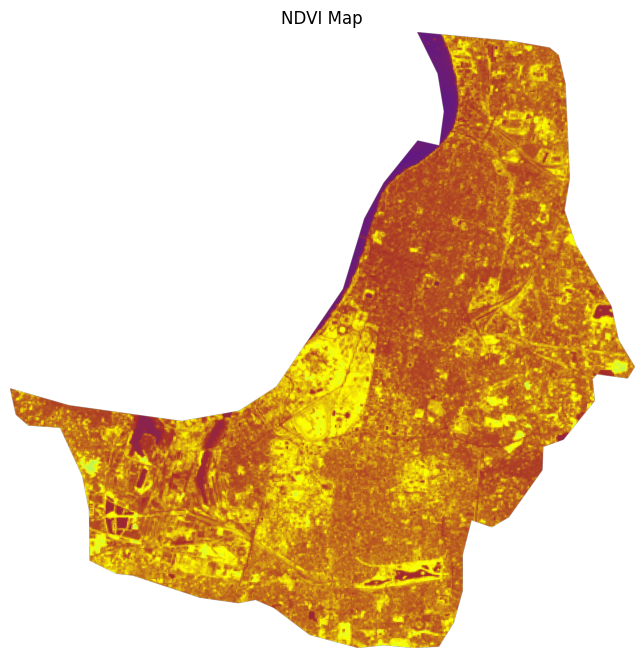

In [ ]:
show_ee_image(
    ndvi,
    {
        'min':-0.2,
        'max':0.8,
        'palette':[
            'blue',
            'brown',
            'yellow',
            'lightgreen',
            'darkgreen'
        ]
    },
    'NDVI Map'
)

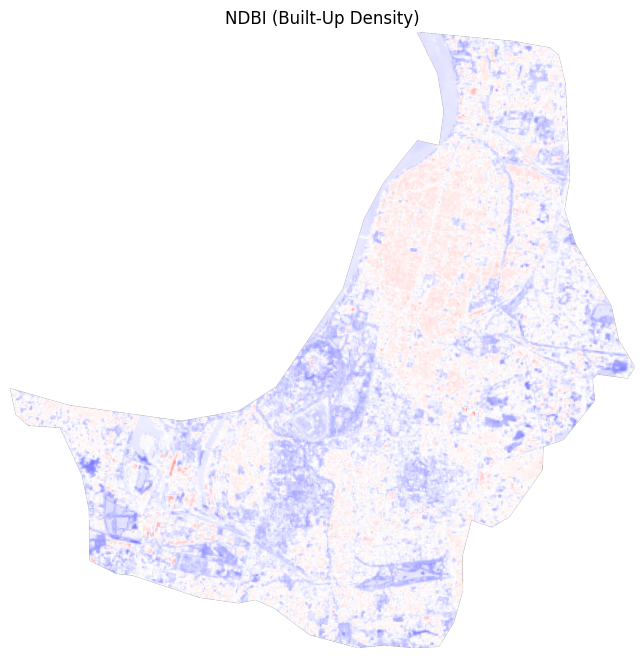

In [ ]:
show_ee_image(
    ndbi,
    {
        'min':-0.5,
        'max':0.5,
        'palette':[
            'blue',
            'white',
            'red'
        ]
    },
    'NDBI (Built-Up Density)'
)

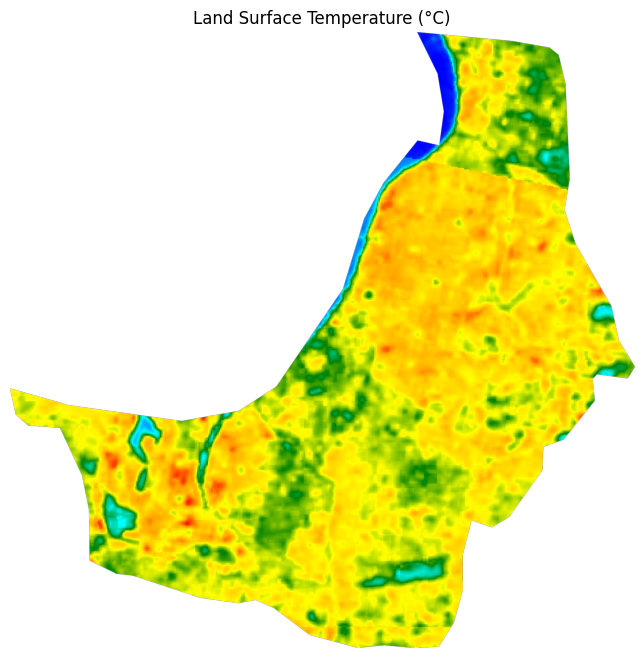

In [ ]:
show_ee_image(
    lst,
    {
        'min':34,
        'max':57,
        'palette':[
            'blue',
            'cyan',
            'green',
            'yellow',
            'orange',
            'red'
        ]
    },
    'Land Surface Temperature (°C)'
)

In [ ]:
lst_class = lst.expression(
"""
b('LST') < 40 ? 1 :
b('LST') < 45 ? 2 :
b('LST') < 50 ? 3 :
b('LST') < 53 ? 4 :
5
"""
).rename('LST_Class')

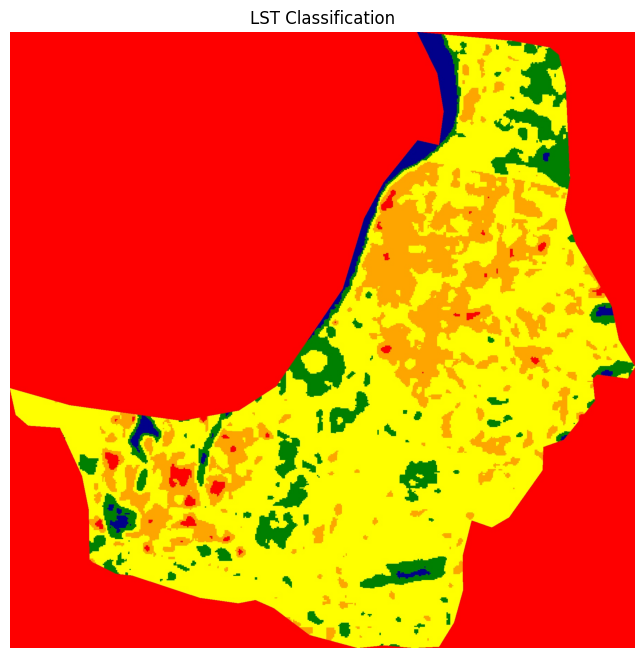

In [ ]:
show_ee_image(
    lst_class,
    {
        'min':1,
        'max':5,
        'palette':[
            'darkblue',
            'green',
            'yellow',
            'orange',
            'red'
        ]
    },
    'LST Classification'
)

In [ ]:
p90 = lst.reduceRegion(
    reducer=ee.Reducer.percentile([90]),
    geometry=aoi.geometry(),
    scale=30,
    maxPixels=1e13
)

key = list(p90.getInfo().keys())[0]

threshold = ee.Number(
    p90.get(key)
)

uhi = lst.gt(threshold)

In [ ]:
print("Threshold =", threshold.getInfo())

Threshold = 50.81126940717706


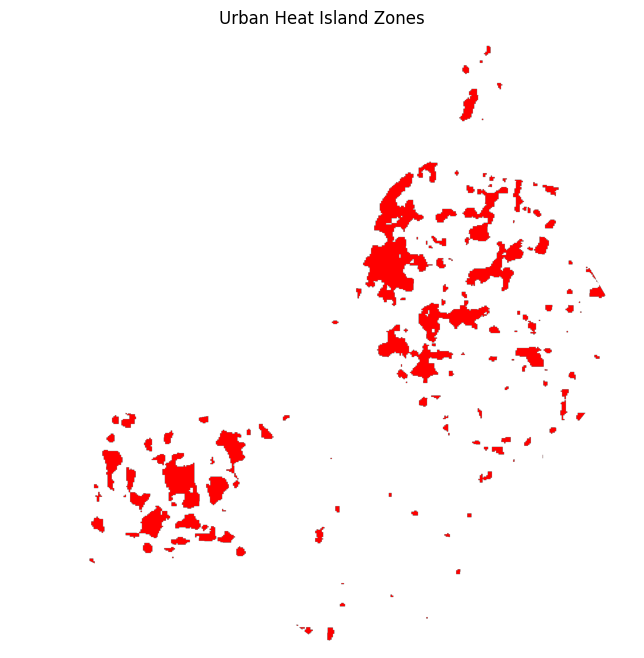

In [ ]:
show_ee_image(
    uhi.selfMask(),
    {
        'palette':['red']
    },
    'Urban Heat Island Zones'
)

In [ ]:
uhi_levels = lst.expression(
"""
b('LST') < 40 ? 1 :
b('LST') < 45 ? 2 :
b('LST') < 50 ? 3 :
b('LST') < 53 ? 4 :
5
"""
).rename('UHI')

This gives:

Color	   Meaning
Green	   Low Heat
Yellow	  Moderate
Orange	  High
Red	Very   High
Dark Red	 Extreme UHI

This usually looks the best in academic reports.

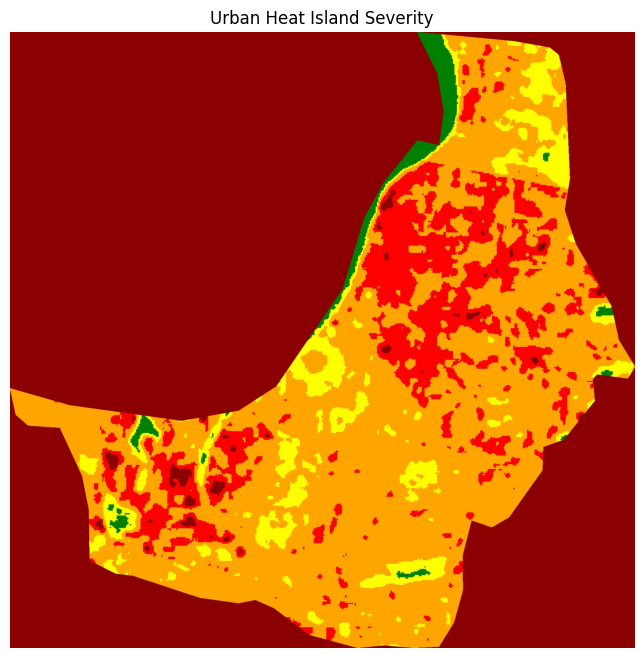

In [ ]:
show_ee_image(
    uhi_levels,
    {
        'min':1,
        'max':5,
        'palette':[
            'green',
            'yellow',
            'orange',
            'red',
            'darkred'
        ]
    },
    'Urban Heat Island Severity'
)

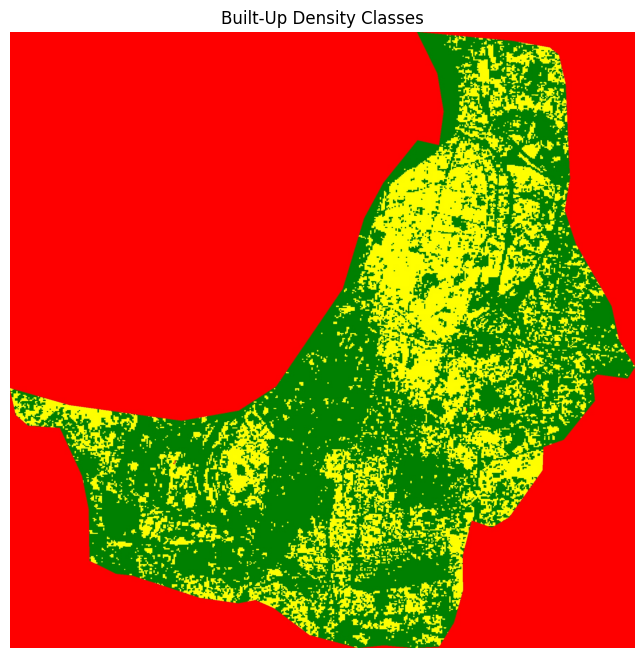

In [ ]:
show_ee_image(
    builtup_class,
    {
        'min':1,
        'max':3,
        'palette':[
            'green',
            'yellow',
            'red'
        ]
    },
    'Built-Up Density Classes'
)

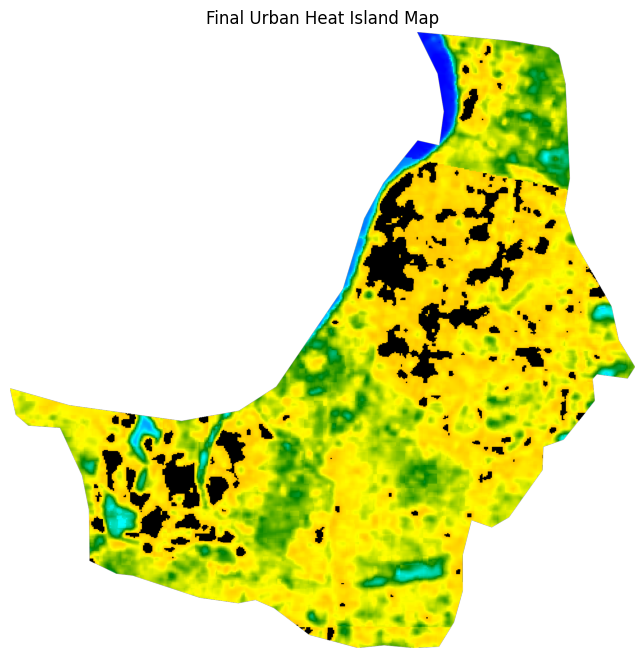

In [ ]:
final_uhi = lst.visualize(
    min=34,
    max=57,
    palette=[
        'blue',
        'cyan',
        'green',
        'yellow',
        'orange',
        'red'
    ]
).blend(
    uhi.selfMask().visualize(
        palette=['black']
    )
)

show_ee_image(
    final_uhi,
    {},
    'Final Urban Heat Island Map'
)

In [ ]:
combined = ndbi.addBands(lst)

samples = combined.sample(
    region=aoi.geometry(),
    scale=30,
    numPixels=5000
)

data = samples.getInfo()['features']

rows = []

for f in data:
    rows.append({
        'NDBI':f['properties']['NDBI'],
        'LST':f['properties']['LST']
    })

df = pd.DataFrame(rows)

df = df.dropna()

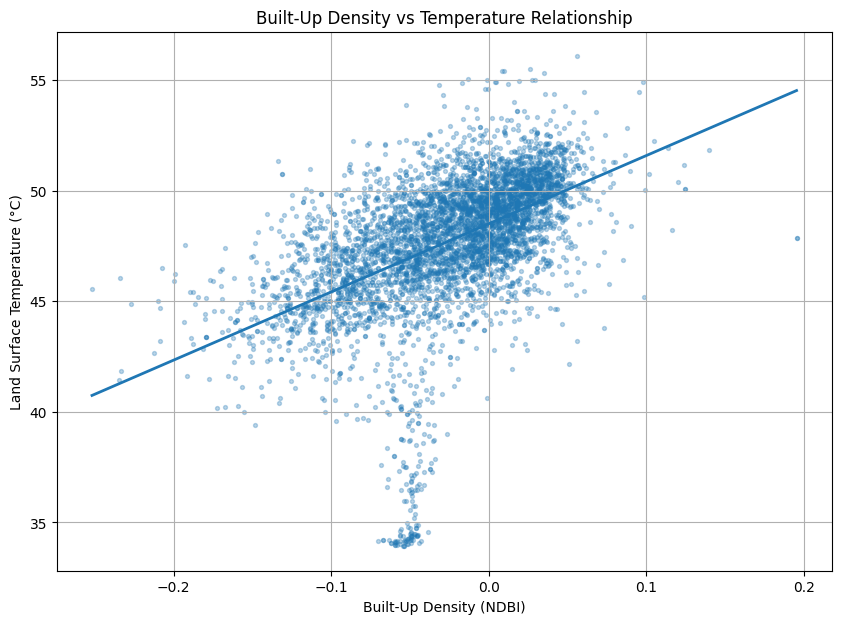

In [ ]:
x = df['NDBI']
y = df['LST']

coef = np.polyfit(x,y,1)
poly = np.poly1d(coef)

plt.figure(figsize=(10,7))

plt.scatter(
    x,
    y,
    alpha=0.3,
    s=8
)

plt.plot(
    np.sort(x),
    poly(np.sort(x)),
    linewidth=2
)

plt.xlabel(
    'Built-Up Density (NDBI)'
)

plt.ylabel(
    'Land Surface Temperature (°C)'
)

plt.title(
    'Built-Up Density vs Temperature Relationship'
)

plt.grid(True)

plt.show()

In [ ]:
corr = df['NDBI'].corr(
    df['LST']
)

print(
    "Correlation between NDBI and LST =",
    round(corr,3)
)

Correlation between NDBI and LST = 0.503
